In [ ]:
# Problem 1: Getting started with data exploration (warm-up)

In [ ]:
# 1 Load dataset and basic overview

In [3]:
# 1.1 Dataset Overview

# Load and show first 10 rows, columns, dtypes
import pandas as pd
df = pd.read_csv("WorldHappinessReport.csv")  
# Quick view
display(df.head(10))
print("Shape (rows, cols):", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298
5,Netherlands,7.319,1.901,1.462,0.706,0.725,0.247,0.372,1.906
6,Norway,7.302,1.952,1.517,0.704,0.835,0.224,0.484,1.586
7,Luxembourg,7.122,2.141,1.355,0.708,0.801,0.146,0.432,1.540
8,Switzerland,7.060,1.970,1.425,0.747,0.759,0.173,0.498,1.488
9,Australia,7.057,1.854,1.461,0.692,0.756,0.225,0.323,1.745


Shape (rows, cols): (143, 9)

Column names and dtypes:
Country name                     object
score                           float64
Log GDP per capita              float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Dystopia + residual             float64
dtype: object


In [9]:
# Basic Statistics

# 1.2 Basic statistics for the Score column
score_col = "score"

mean_score = df[score_col].mean()
median_score = df[score_col].median()
std_score = df[score_col].std(ddof=1)  

print(f"Mean {score_col}: {mean_score:.4f}")
print(f"Median {score_col}: {median_score:.4f}")
print(f"Std dev {score_col}: {std_score:.4f}")


Mean score: 5.5276
Median score: 5.7850
Std dev score: 1.1707


In [12]:
# 1.2 Highest and lowest scoring countries

country_col = "Country name"

highest = df.loc[df[score_col].idxmax(), [country_col, score_col]]
lowest = df.loc[df[score_col].idxmin(), [country_col, score_col]]
print("Highest scoring country:")
display(highest)
print("\nLowest scoring country:")
display(lowest)


Highest scoring country:


Country name    Finland
score             7.741
Name: 0, dtype: object


Lowest scoring country:


Country name    Afghanistan
score                 1.721
Name: 142, dtype: object

In [13]:
# Missing Values

# 1.3 Missing values count per column
print("Missing values per column:")
display(df.isna().sum())


Missing values per column:


Country name                    0
score                           0
Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64

In [15]:
# Filtering and Sorting

# 1.4 Filter: Score > 7.5 and sort by GDP per Capita (descending), show top 10
gdp_col = "Log GDP per capita"  

filtered = df[df[score_col] > 7.5].copy()
filtered_sorted = filtered.sort_values(by=gdp_col, ascending=False)
display(filtered_sorted.head(10))


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082


In [16]:
# Adding New Columns

# 1.5 Add Happiness Category column
def categorize(score):
    if score < 4: return "Low"
    elif score <= 6: return "Medium"
    else: return "High"

df["Happiness Category"] = df[score_col].apply(categorize)
display(df[[country_col, score_col, "Happiness Category"]].head(10))


,Country name,score,Happiness Category
0,Finland,7.741,High
1,Denmark,7.583,High
2,Iceland,7.525,High
3,Sweden,7.344,High
4,Israel,7.341,High
5,Netherlands,7.319,High
6,Norway,7.302,High
7,Luxembourg,7.122,High
8,Switzerland,7.060,High
9,Australia,7.057,High


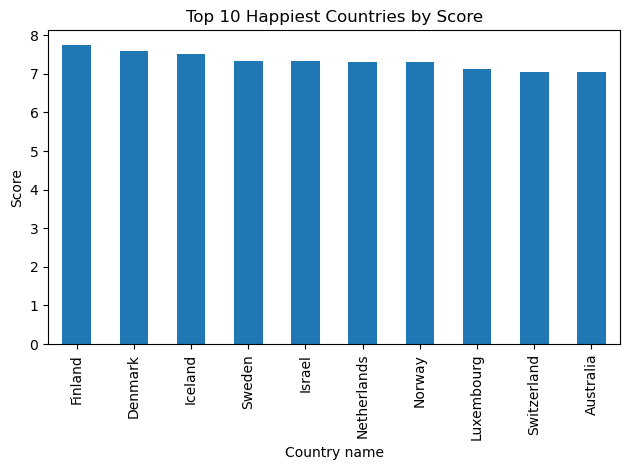

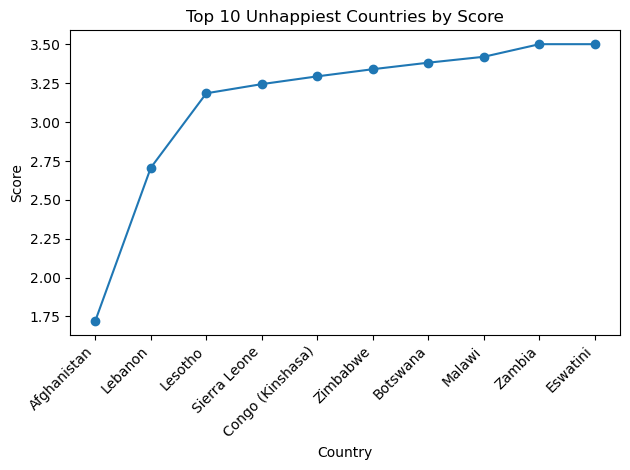

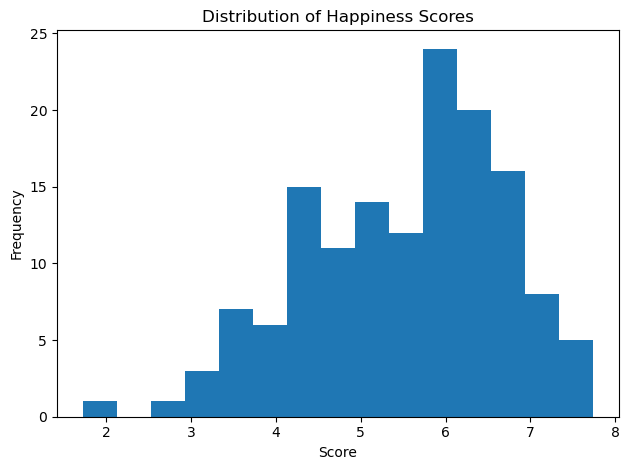

Score skewness: -0.5218 (positive means right-skewed, negative left-skewed)


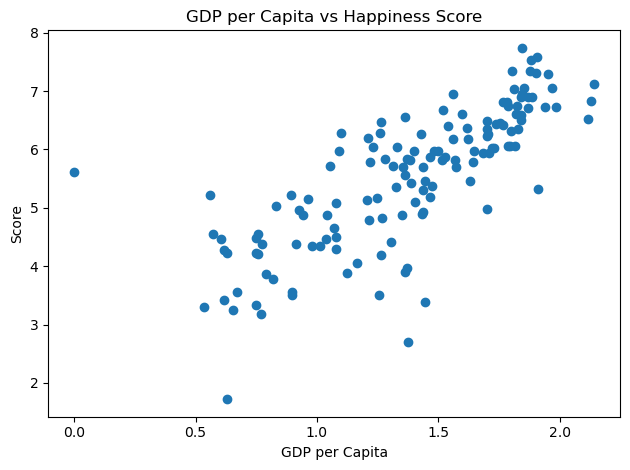

Pearson correlation between Log GDP per capita and score: 0.7685


In [20]:
# 2. Data Visualizations

# 1.6 Visualizations (bar, line, histogram, scatter)

import matplotlib.pyplot as plt
# Define column names
country_col = "Country name"
gdp_col = "Log GDP per capita"
score_col = "score"  

# Top 10 happiest (bar chart)
top10 = df.nlargest(10, score_col).set_index(country_col)
top10[score_col].plot(kind='bar', title="Top 10 Happiest Countries by Score")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# Top 10 unhappiest (line chart) - smallest scores
bottom10 = df.nsmallest(10, score_col).sort_values(by=score_col)
plt.plot(bottom10[country_col], bottom10[score_col], marker='o')
plt.title("Top 10 Unhappiest Countries by Score")
plt.xlabel("Country")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Histogram for Score with simple interpretation printed after
plt.hist(df[score_col].dropna(), bins=15)
plt.title("Distribution of Happiness Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Simple interpretation print:
skewness = df[score_col].skew()
print(f"Score skewness: {skewness:.4f} (positive means right-skewed, negative left-skewed)")

# Scatter: GDP per Capita vs Score
plt.scatter(df[gdp_col], df[score_col])
plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# Show Pearson correlation
corr = df[[gdp_col, score_col]].dropna().corr().iloc[0,1]
print(f"Pearson correlation between {gdp_col} and {score_col}: {corr:.4f}")


In [ ]:
# Problem - 2 - Some Advance Data Exploration Task

In [6]:
# Task-1

# 2.1 Prepare South Asia dataset

import pandas as pd

# Load dataset
df = pd.read_csv("WorldHappinessReport.csv")
country_col = "Country name"
score_col = "score"

# 1. Define the countries in South Asia
south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India",
              "Maldives", "Nepal", "Pakistan", "Srilanka", "Sri Lanka"]  

# 2. Filter the dataset
df_country_clean = df.copy()
df_country_clean[country_col] = df_country_clean[country_col].str.strip()
south_df = df_country_clean[df_country_clean[country_col].isin(south_asia)].copy()
print("South Asia rows found:", south_df.shape[0])
display(south_df)

# 3. Save the filtered dataframe
south_df.to_csv("South_Asia_WorldHappiness.csv", index=False)
print("Saved South_Asia_WorldHappiness.csv")



South Asia rows found: 6


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672


Saved South_Asia_WorldHappiness.csv


,Country name,Composite Score,score
0,Sri Lanka,1.0739,3.898
1,Nepal,0.8159,5.158
2,India,0.7874,4.054
3,Pakistan,0.7039,4.657
4,Bangladesh,0.6774,3.886
5,Afghanistan,0.3238,1.721


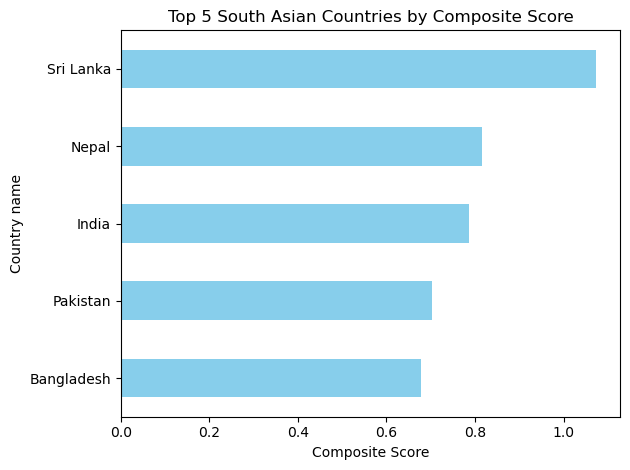

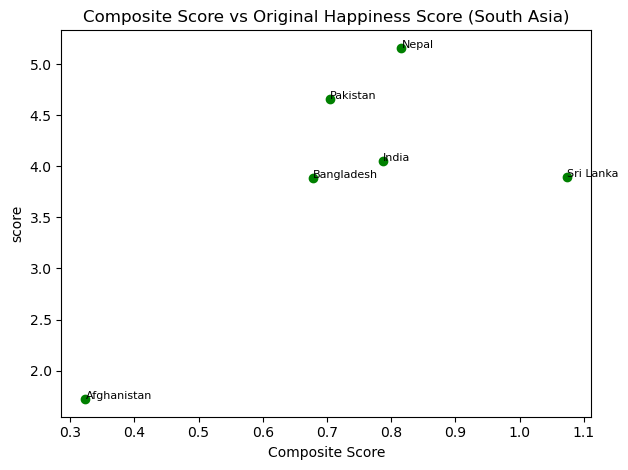

Pearson correlation between Composite Score and original Score: 0.6844


In [9]:
# Task-2

# Composite Score Ranking

import matplotlib.pyplot as plt

# Define columns 
gdp_col = "Log GDP per capita"
social_col = "Social support"
health_col = "Healthy life expectancy"
country_col = "Country name"
score_col = "score"

# 1. Composite Score formula:
south_df["Composite Score"] = 0.40 * south_df[gdp_col] + \
                              0.30 * south_df[social_col] + \
                              0.30 * south_df[health_col]

# 2. Composite Score in descending order
south_df = south_df.sort_values(by="Composite Score", ascending=False).reset_index(drop=True)
display(south_df[[country_col, "Composite Score", score_col]])

# 3. Top 5 horizontal bar chart
top5_comp = south_df.head(5).set_index(country_col)
top5_comp["Composite Score"].plot(kind='barh', color='skyblue', title="Top 5 South Asian Countries by Composite Score")
plt.xlabel("Composite Score")
plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

# 4. Compare Composite Score with original Happiness Score
# Scatter plot
plt.scatter(south_df["Composite Score"], south_df[score_col], color="green")
for i, row in south_df.iterrows():
    plt.text(row["Composite Score"], row[score_col], row[country_col], fontsize=8)    
plt.title("Composite Score vs Original Happiness Score (South Asia)")
plt.xlabel("Composite Score")
plt.ylabel(score_col)
plt.tight_layout()
plt.show()

# Pearson correlation
corr = south_df[["Composite Score", score_col]].corr().iloc[0,1]
print(f"Pearson correlation between Composite Score and original Score: {corr:.4f}")



Score outlier bounds: (2.963125000000001, 5.432124999999999)
GDP per Capita outlier bounds: (0.7449999999999999, 1.401)

Score outliers (countries):


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Composite Score
5,Afghanistan,1.721,0.628,0.0,0.242,0.0,0.091,0.088,0.672,0.3238



GDP outliers (countries):


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Composite Score
5,Afghanistan,1.721,0.628,0.0,0.242,0.0,0.091,0.088,0.672,0.3238


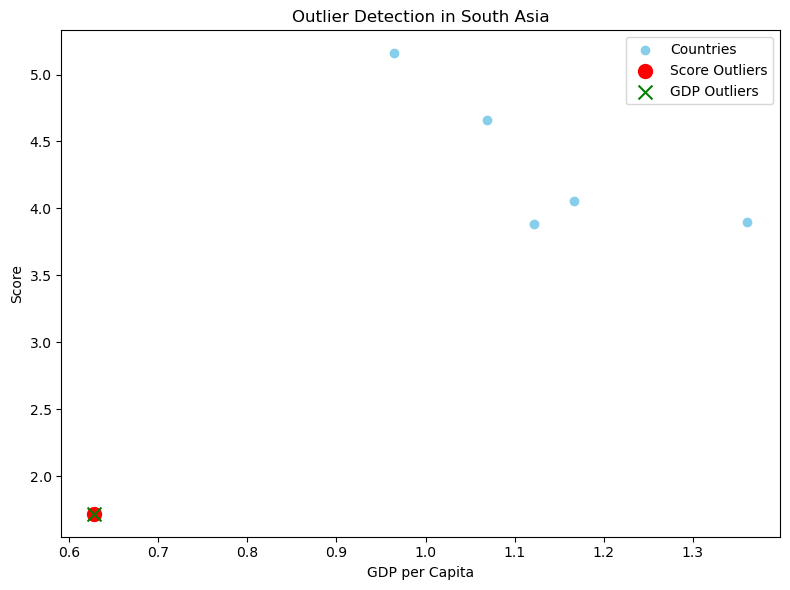

Discussion:
Outliers represent countries with unusually high or low Scores or GDP per Capita compared to the rest of South Asia.
These outliers can skew regional averages and may need special consideration in analysis.


In [12]:
# Task - 3: Outlier Detection

import matplotlib.pyplot as plt

# 1 & 2. Identify outlier countries in South Asia using 1.5 × IQR rule

def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], (lower, upper)

score_outliers, score_bounds = find_iqr_outliers(south_df[score_col].dropna())
gdp_outliers, gdp_bounds = find_iqr_outliers(south_df[gdp_col].dropna())

print("Score outlier bounds:", score_bounds)
print("GDP per Capita outlier bounds:", gdp_bounds)

print("\nScore outliers (countries):")
display(south_df[south_df[score_col].isin(score_outliers)])

print("\nGDP outliers (countries):")
display(south_df[south_df[gdp_col].isin(gdp_outliers)])

# 3. Scatter plot with GDP per Capita vs Score, highlighting outliers
plt.figure(figsize=(8,6))
plt.scatter(south_df[gdp_col], south_df[score_col], label="Countries", color="skyblue")

plt.scatter(south_df[south_df[score_col].isin(score_outliers)][gdp_col],
            south_df[south_df[score_col].isin(score_outliers)][score_col],
            color="red", label="Score Outliers", s=100)

plt.scatter(south_df[south_df[gdp_col].isin(gdp_outliers)][gdp_col],
            south_df[south_df[gdp_col].isin(gdp_outliers)][score_col],
            color="green", label="GDP Outliers", s=100, marker="x")

plt.xlabel("GDP per Capita")
plt.ylabel("Score")
plt.title("Outlier Detection in South Asia")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Discussion
print("Discussion:")
print("Outliers represent countries with unusually high or low Scores or GDP per Capita compared to the rest of South Asia.")
print("These outliers can skew regional averages and may need special consideration in analysis.")



The correlation value for Score and Freedom is 0.801
The correlation value for Score and Generosity is 0.875


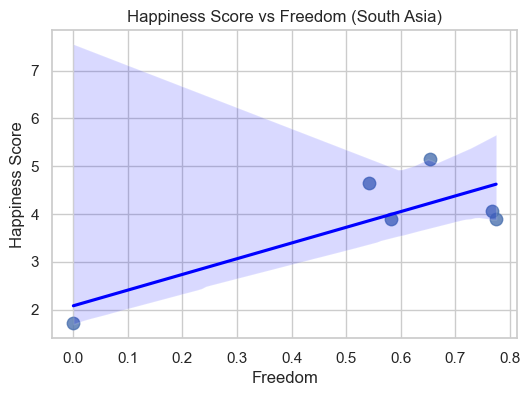

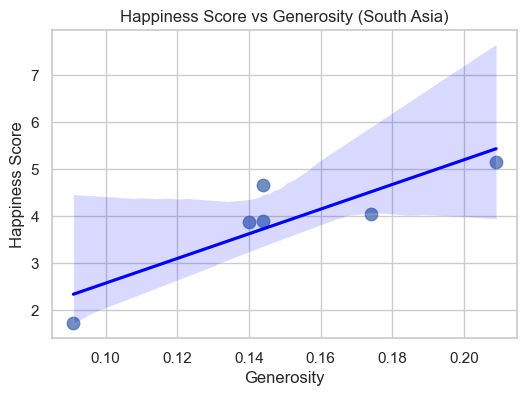


Strongest relationship: Generosity (r = 0.875)
Weakest relationship: Freedom (r = 0.801)


In [48]:
# Task - 4 - Exploring Trends Across Metrics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

south_asia_df = pd.read_csv("South_Asia_WorldHappiness.csv")

# Standardize column names
south_asia_df.rename(columns={
    'Freedom to make life choices': 'Freedom',
    'Healthy life expectancy': 'Life Expectancy',
    'Social support': 'Social Support',
    'score': 'Score'
}, inplace=True)

# Correlations
metrics = ['Freedom', 'Generosity']
corr_values = {}

for metric in metrics:
    corr, _ = pearsonr(south_asia_df[metric], south_asia_df['Score'])
    corr_values[metric] = corr
    print(f"The correlation value for Score and {metric} is {corr:.3f}")

# Scatter plots with trendlines
for metric in metrics:
    plt.figure(figsize=(6,4))
    sns.regplot(x=metric, y='Score', data=south_asia_df,
                scatter_kws={'s':80}, line_kws={'color':'blue'})
    plt.title(f'Happiness Score vs {metric} (South Asia)')
    plt.xlabel(metric)
    plt.ylabel('Happiness Score')
    plt.show()

# Strongest and weakest relationships
strongest = max(corr_values, key=lambda m: abs(corr_values[m]))
weakest = min(corr_values, key=lambda m: abs(corr_values[m]))

print("\nStrongest relationship:", strongest, f"(r = {corr_values[strongest]:.3f})")
print("Weakest relationship:", weakest, f"(r = {corr_values[weakest]:.3f})")

Top 3 largest negative gaps (GDP much less than Score):


,Country name,Log GDP per capita,score,GDP-Score Gap
0,Nepal,0.965,5.158,-4.193
1,Pakistan,1.069,4.657,-3.588
2,India,1.166,4.054,-2.888



Top 3 largest positive gaps (GDP much greater than Score):


,Country name,Log GDP per capita,score,GDP-Score Gap
0,Afghanistan,0.628,1.721,-1.093
1,Sri Lanka,1.361,3.898,-2.537
2,Bangladesh,1.122,3.886,-2.764


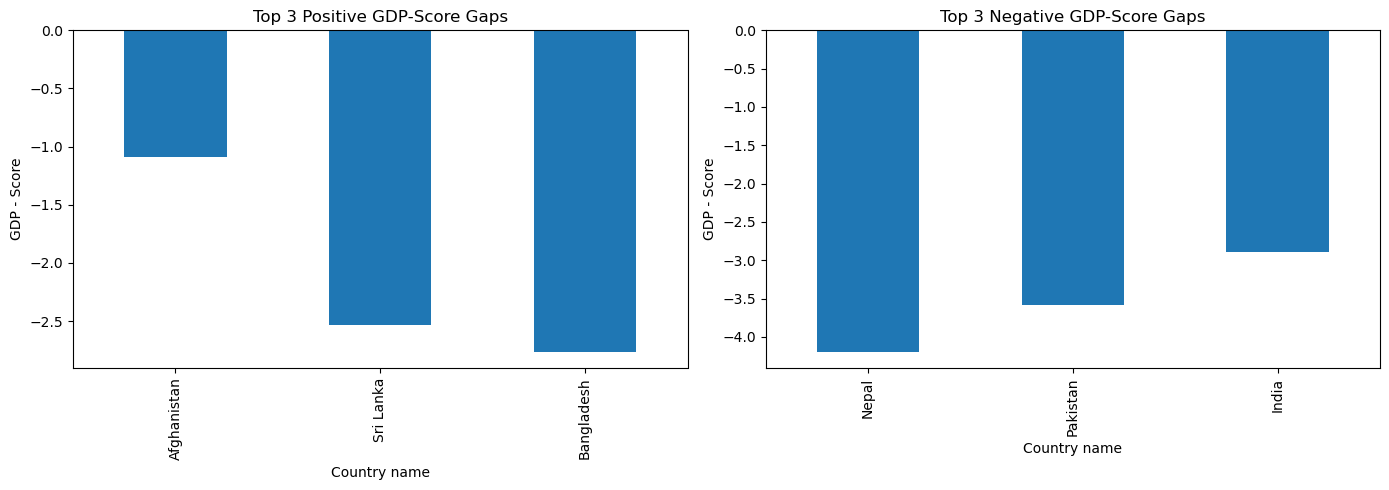

Analysis:
Countries with positive gaps have higher GDP per Capita compared to their Happiness Score, indicating that economic wealth may not fully translate to happiness.
Countries with negative gaps have lower GDP per Capita compared to their Happiness Score, suggesting strong social, health, or other factors contributing to happiness despite lower economic wealth.


In [14]:
# Task - 5 - Gap Analysis

import matplotlib.pyplot as plt

# 1. Add a new column, GDP-Score Gap
south_df["GDP-Score Gap"] = south_df[gdp_col] - south_df[score_col]

# 2. Rank the South Asian countries by this gap

# Ascending order
asc = south_df.sort_values(by="GDP-Score Gap").reset_index(drop=True)
# Descending order
desc = south_df.sort_values(by="GDP-Score Gap", ascending=False).reset_index(drop=True)

print("Top 3 largest negative gaps (GDP much less than Score):")
display(asc.head(3)[[country_col, gdp_col, score_col, "GDP-Score Gap"]])

print("\nTop 3 largest positive gaps (GDP much greater than Score):")
display(desc.head(3)[[country_col, gdp_col, score_col, "GDP-Score Gap"]])

# 3. Highlight top 3 positive and negative gaps using a bar chart
top_pos = desc.head(3).set_index(country_col)["GDP-Score Gap"]
top_neg = asc.head(3).set_index(country_col)["GDP-Score Gap"]

fig, axes = plt.subplots(1,2, figsize=(14,5))
top_pos.plot(kind='bar', ax=axes[0], title="Top 3 Positive GDP-Score Gaps")
axes[0].set_ylabel("GDP - Score")
top_neg.plot(kind='bar', ax=axes[1], title="Top 3 Negative GDP-Score Gaps")
axes[1].set_ylabel("GDP - Score")
plt.tight_layout()
plt.show()

# 4. Analyze the reasons behind these gaps
print("Analysis:")
print("Countries with positive gaps have higher GDP per Capita compared to their Happiness Score, indicating that economic wealth may not fully translate to happiness.")
print("Countries with negative gaps have lower GDP per Capita compared to their Happiness Score, suggesting strong social, health, or other factors contributing to happiness despite lower economic wealth.")


In [ ]:
# Problem - 3 - Comparative Analysis

In [6]:
# Task - 1 - Setup Task - Preparing the Middle Eastern Dataset

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df_country_clean = pd.read_csv("WorldHappinessReport.csv")  

# 1. Prepare Middle East dataset
country_col = "Country name"  

middle_east = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan",
               "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
               "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"]

me_df = df_country_clean[df_country_clean[country_col].isin(middle_east)].copy()
print("Middle East rows found:", me_df.shape[0])
display(me_df.head(10))


Middle East rows found: 10


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298
12,Kuwait,6.951,1.845,1.364,0.661,0.827,0.200,0.172,1.884
21,United Arab Emirates,6.733,1.983,1.164,0.563,0.815,0.209,0.258,1.741
27,Saudi Arabia,6.594,1.842,1.361,0.511,0.787,0.114,0.188,1.790
61,Bahrain,5.959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,Iraq,5.166,1.249,0.996,0.498,0.425,0.141,0.048,1.809
99,Iran,4.923,1.435,1.136,0.571,0.366,0.235,0.123,1.057
124,Jordan,4.186,1.262,0.983,0.594,0.593,0.059,0.189,0.504
132,Yemen,3.561,0.671,1.281,0.293,0.362,0.080,0.113,0.760
141,Lebanon,2.707,1.377,0.577,0.556,0.173,0.068,0.029,-0.073


In [16]:
# 1. Descriptive Statistics: Mean & Std

south_score_mean = south_df[score_col].mean()
south_score_std = south_df[score_col].std(ddof=1)
me_score_mean = me_df[score_col].mean()
me_score_std = me_df[score_col].std(ddof=1)

print("South Asia - Mean:", round(south_score_mean,3), "Std:", round(south_score_std,3))
print("Middle East - Mean:", round(me_score_mean,3), "Std:", round(me_score_std,3))

if south_score_mean > me_score_mean:
    print("South Asia has higher average happiness (mean).")
else:
    print("Middle East has higher average happiness (mean).")

South Asia - Mean: 3.896 Std: 1.177
Middle East - Mean: 5.412 Std: 1.566
Middle East has higher average happiness (mean).



South Asia - Top 3


,Country name,score
92,Nepal,5.158
107,Pakistan,4.657
125,India,4.054



South Asia - Bottom 3


,Country name,score
142,Afghanistan,1.721
128,Bangladesh,3.886
127,Sri Lanka,3.898



Middle East - Top 3


,Country name,score
4,Israel,7.341
12,Kuwait,6.951
21,United Arab Emirates,6.733



Middle East - Bottom 3


,Country name,score
141,Lebanon,2.707
132,Yemen,3.561
124,Jordan,4.186


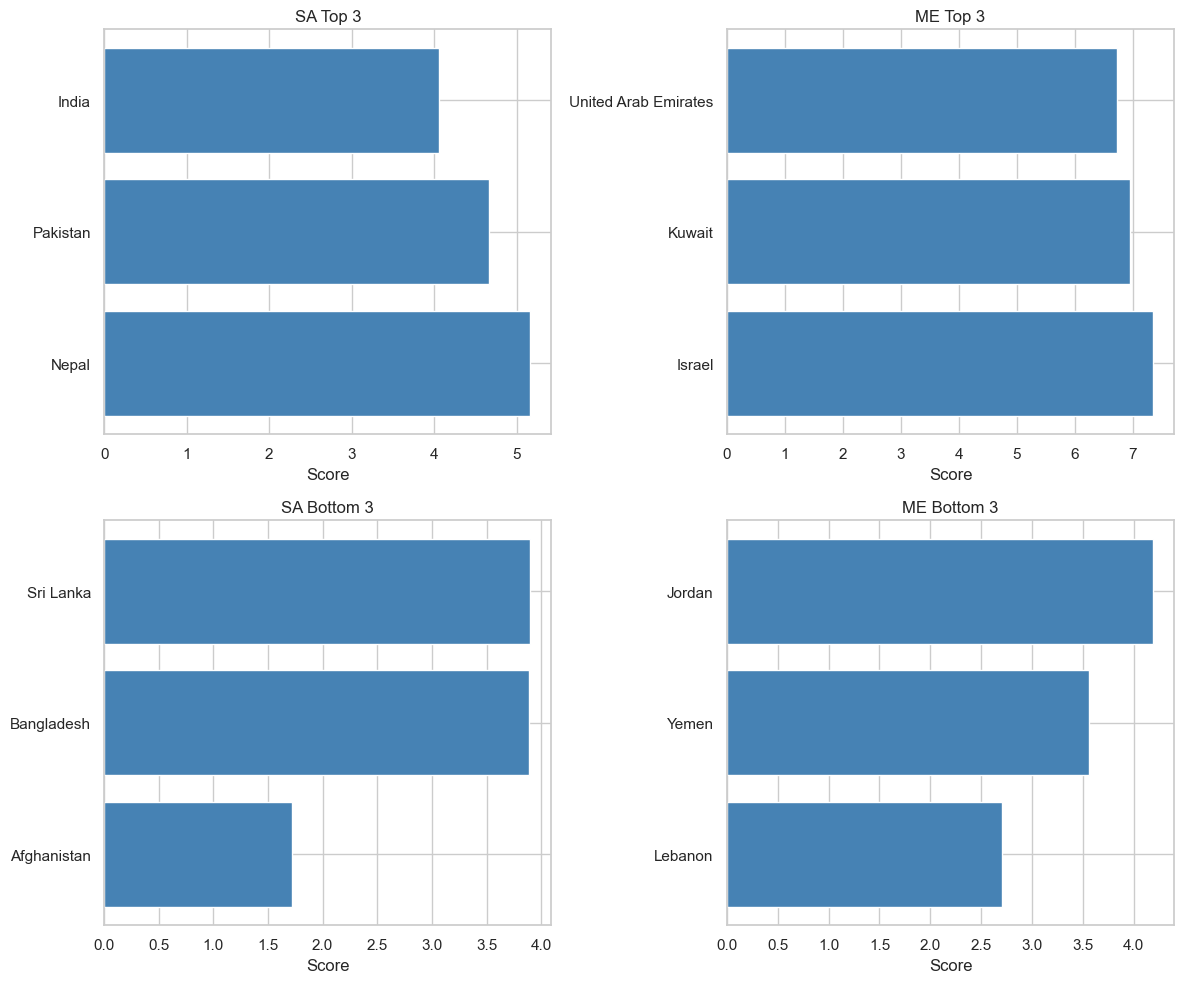

In [19]:
# 2. Top and Bottom Performers
country_col = "Country name"

# Prepare Middle East dataset
middle_east_countries = ["Israel", "Kuwait", "United Arab Emirates", "Lebanon", "Yemen", "Jordan", "Saudi Arabia", "Iraq", "Qatar", "Oman", "Bahrain"]
me_df = data[data[country_col].isin(middle_east_countries)]

def top_bottom(df_region, region_name):
    top3 = df_region.nlargest(3, score_col)[[country_col, score_col]]
    bot3 = df_region.nsmallest(3, score_col)[[country_col, score_col]]
    print(f"\n{region_name} - Top 3")
    display(top3)
    print(f"\n{region_name} - Bottom 3")
    display(bot3)
    return top3, bot3
# Get top/bottom for both regions
sa_top, sa_bottom = top_bottom(south_df, "South Asia")
me_top, me_bottom = top_bottom(me_df, "Middle East")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# South Asia Top 3
axes[0, 0].barh(sa_top[country_col], sa_top[score_col], color="steelblue")
axes[0, 0].set_title("SA Top 3")
axes[0, 0].set_xlabel("Score")

# Middle East Top 3
axes[0, 1].barh(me_top[country_col], me_top[score_col], color="steelblue")
axes[0, 1].set_title("ME Top 3")
axes[0, 1].set_xlabel("Score")

# South Asia Bottom 3
axes[1, 0].barh(sa_bottom[country_col], sa_bottom[score_col], color="steelblue")
axes[1, 0].set_title("SA Bottom 3")
axes[1, 0].set_xlabel("Score")

# Middle East Bottom 3
axes[1, 1].barh(me_bottom[country_col], me_bottom[score_col], color="steelblue")
axes[1, 1].set_title("ME Bottom 3")
axes[1, 1].set_xlabel("Score")

plt.tight_layout()
plt.show()

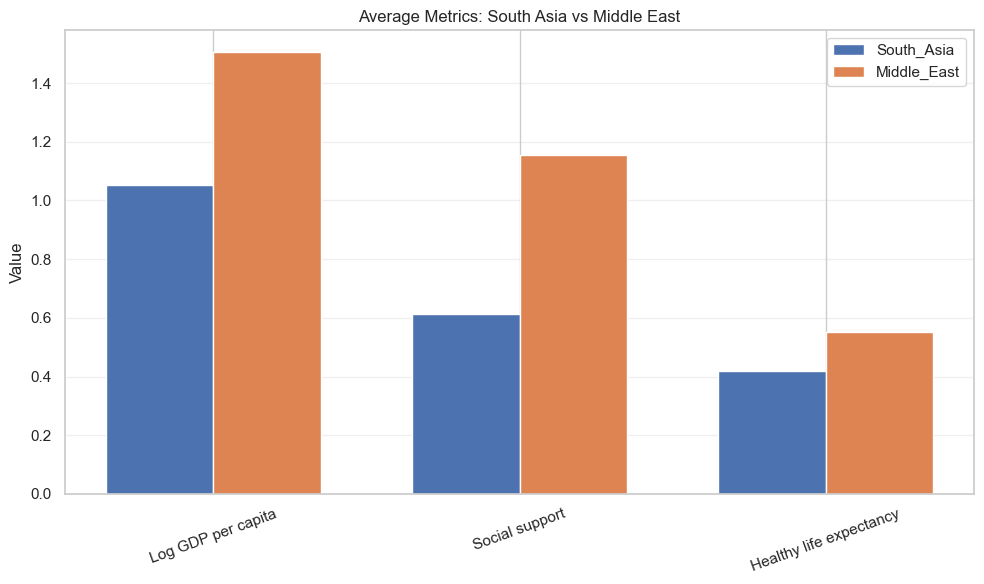

,Metric,South_Asia,Middle_East,Difference
0,Log GDP per capita,1.051833,1.504000,0.452167
1,Social support,0.611833,1.154875,0.543042
2,Healthy life expectancy,0.420333,0.552000,0.131667


In [23]:
# 3. Metric Comparisons: GDP, Social Support, Healthy Life Expectancy
gdp_col = [c for c in data.columns if "gdp" in c.lower()][0]
social_col = [c for c in data.columns if "social" in c.lower()][0]
health_col = [c for c in data.columns if "health" in c.lower()][0]

metrics = [gdp_col, social_col, health_col]

region_means = pd.DataFrame({
    "Metric": metrics,
    "South_Asia": south_df[metrics].mean().values,
    "Middle_East": me_df[metrics].mean().values
})

region_means["Difference"] = region_means["Middle_East"] - region_means["South_Asia"]
plt.figure(figsize=(10,6))
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, region_means["South_Asia"], width, label="South_Asia")
plt.bar(x + width/2, region_means["Middle_East"], width, label="Middle_East")
plt.xticks(x, metrics, rotation=20)
plt.ylabel("Value")
plt.title("Average Metrics: South Asia vs Middle East")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
display(region_means)


In [25]:
# 4. Happiness Disparity: Range & Coefficient of Variation

def summarize_variability(df_region, name):
    rng = df_region[score_col].max() - df_region[score_col].min()
    mean = df_region[score_col].mean()
    std = df_region[score_col].std(ddof=1)
    cv = std / mean if mean != 0 else np.nan
    print(f"{name} – Range: {rng:.3f}, CV: {cv:.3f}")
    return rng, cv

sa_range, sa_cv = summarize_variability(south_df, "South Asia")
me_range, me_cv = summarize_variability(me_df, "Middle East")

if sa_cv > me_cv:
    print("\nSouth Asia shows greater variation in happiness scores.")
else:
    print("\nMiddle East shows greater variation in happiness scores.")


South Asia – Range: 3.437, CV: 0.302
Middle East – Range: 4.634, CV: 0.302

South Asia shows greater variation in happiness scores.


 Correlation Analysis for South Asia 
Pearson correlation between score and Freedom to make life choices: 0.801


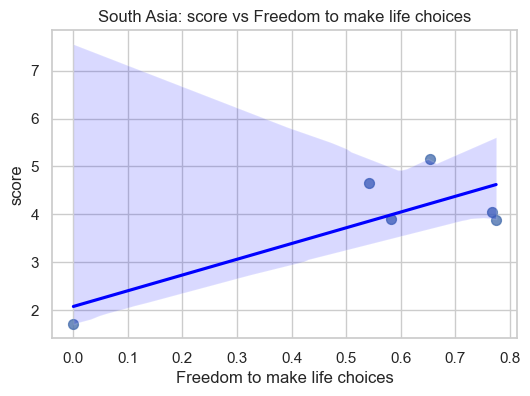

Pearson correlation between score and Generosity: 0.875


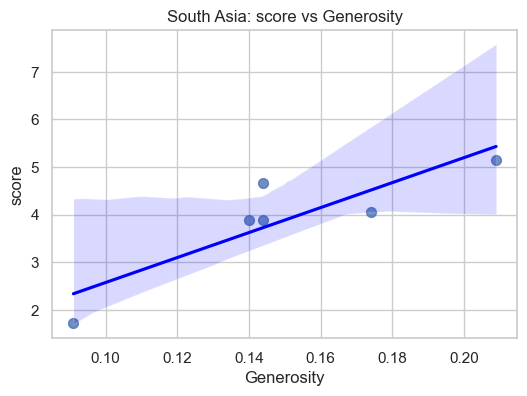

 Correlation Analysis for Middle East 
Pearson correlation between score and Freedom to make life choices: 0.849


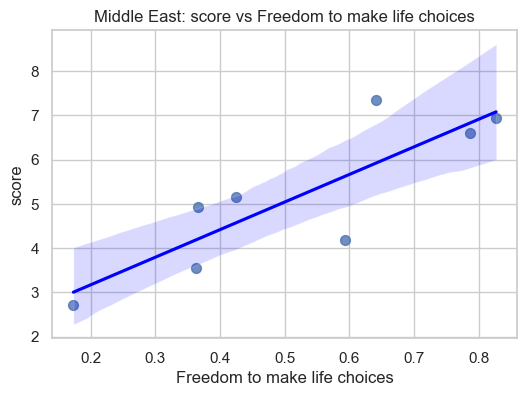

Pearson correlation between score and Generosity: 0.577


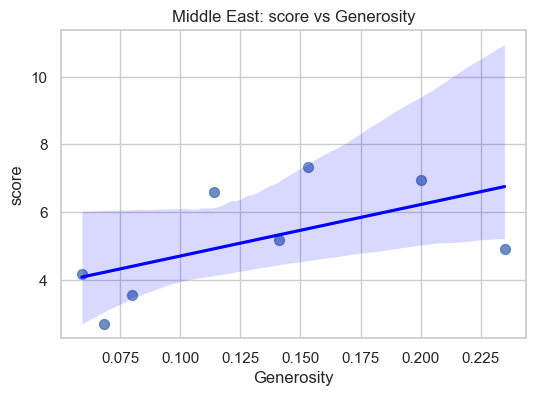

In [58]:
# Task5 -Correlation Analysis:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

data = pd.read_csv("WorldHappinessReport.csv")

south_asia_countries = ["India", "Pakistan", "Nepal", "Bangladesh", "Sri Lanka", "Bhutan", "Maldives", "Afghanistan"]
middle_east_countries = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait", "Lebanon",
                         "Oman", "Qatar", "Saudi Arabia", "Syria", "UAE", "Yemen"]

# Create region-specific DataFrames
south_asia_df = data[data["Country name"].isin(south_asia_countries)]
middle_east_df = data[data["Country name"].isin(middle_east_countries)]

metrics = ['Freedom to make life choices', 'Generosity']

# Function to compute correlations and plot scatter with trendline
def analyze_correlation(df, region_name):
    print(f" Correlation Analysis for {region_name} ")
    
    # Drop rows with NaNs in score or selected metrics
    df_clean = df.dropna(subset=metrics + ['score'])
    
    for metric in metrics:
        corr, _ = pearsonr(df_clean[metric], df_clean['score'])
        print(f"Pearson correlation between score and {metric}: {corr:.3f}")
        
        # Scatter plot with trendline
        plt.figure(figsize=(6,4))
        sns.regplot(x=metric, y='score', data=df_clean,
                    scatter_kws={'s':50}, line_kws={'color':'blue'})
        plt.title(f"{region_name}: score vs {metric}")
        plt.xlabel(metric)
        plt.ylabel("score")
        plt.show()

# Analyze South Asia
analyze_correlation(south_asia_df, "South Asia")
# Analyze Middle East
analyze_correlation(middle_east_df, "Middle East")


South Asia - Score Outliers:
     Country name  score
142  Afghanistan  1.721
South Asia - Log GDP Outliers:
     Country name   log_GDP
142  Afghanistan -0.465215

Middle East - Score Outliers:
 Empty DataFrame
Columns: [Country name, score]
Index: []
Middle East - Log GDP Outliers:
     Country name   log_GDP
132        Yemen -0.398986


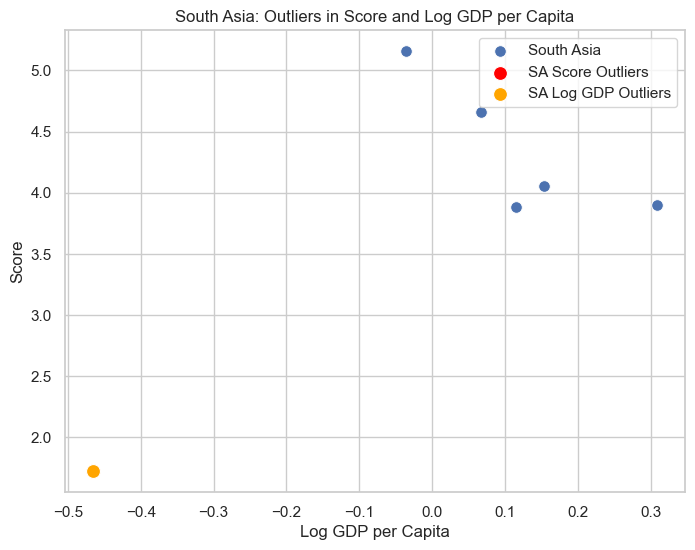

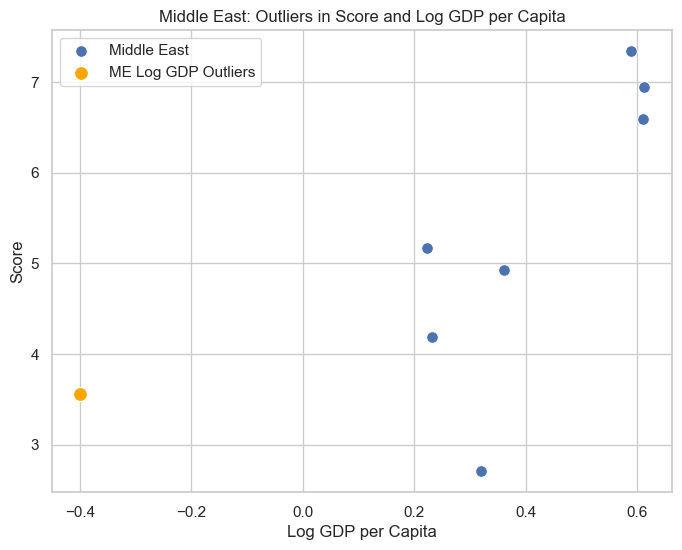

In [74]:
# Task6 - Outlier Detection: Score & Log GDP per Capita
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to detect outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Make sure slices are copies to avoid SettingWithCopyWarning
south_asia_df = south_asia_df.copy()
middle_east_df = middle_east_df.copy()

# Strip column names to remove spaces
south_asia_df.columns = south_asia_df.columns.str.strip()
middle_east_df.columns = middle_east_df.columns.str.strip()

# Column names (update according to your dataset)
score_col = "score"
gdp_col = "Log GDP per capita"
country_col = "Country name"  # change if your column name is different

# Add Log GDP column
south_asia_df['log_GDP'] = np.log(south_asia_df[gdp_col])
middle_east_df['log_GDP'] = np.log(middle_east_df[gdp_col])

# Detect outliers
sa_score_outliers = detect_outliers(south_asia_df, score_col)
sa_gdp_outliers = detect_outliers(south_asia_df, 'log_GDP')

me_score_outliers = detect_outliers(middle_east_df, score_col)
me_gdp_outliers = detect_outliers(middle_east_df, 'log_GDP')

# Print outlier countries
print("South Asia - Score Outliers:\n", sa_score_outliers[[country_col, score_col]])
print("South Asia - Log GDP Outliers:\n", sa_gdp_outliers[[country_col, 'log_GDP']])

print("\nMiddle East - Score Outliers:\n", me_score_outliers[[country_col, score_col]])
print("Middle East - Log GDP Outliers:\n", me_gdp_outliers[[country_col, 'log_GDP']])

# Visualization using scatter plots
plt.figure(figsize=(8,6))
sns.scatterplot(data=south_asia_df, x='log_GDP', y=score_col, label='South Asia', s=70)
sns.scatterplot(data=sa_score_outliers, x='log_GDP', y=score_col, color='red', label='SA Score Outliers', s=100)
sns.scatterplot(data=sa_gdp_outliers, x='log_GDP', y=score_col, color='orange', label='SA Log GDP Outliers', s=100)
plt.title("South Asia: Outliers in Score and Log GDP per Capita")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Score")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=middle_east_df, x='log_GDP', y=score_col, label='Middle East', s=70)
sns.scatterplot(data=me_score_outliers, x='log_GDP', y=score_col, color='red', label='ME Score Outliers', s=100)
sns.scatterplot(data=me_gdp_outliers, x='log_GDP', y=score_col, color='orange', label='ME Log GDP Outliers', s=100)
plt.title("Middle East: Outliers in Score and Log GDP per Capita")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Score")
plt.legend()
plt.show()


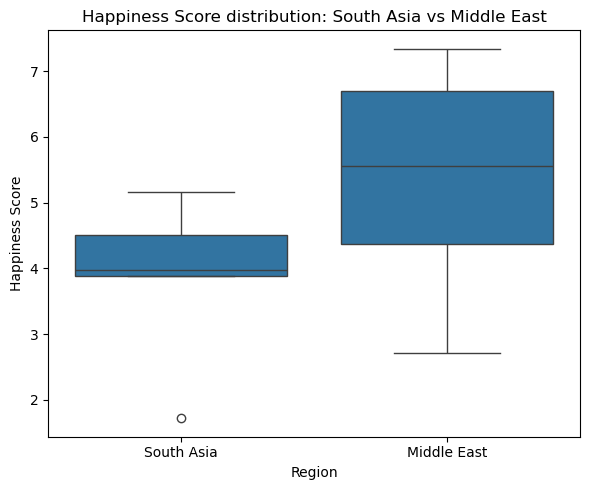

Median Happiness Score - South Asia: 3.98, Middle East: 5.56
Interpretation:
- South Asia vs Middle East: Compare medians to see which region is generally happier.
- The spread (interquartile range) shows variability in scores.
- Outliers are points beyond whiskers; they indicate unusually high or low scores relative to the region.


In [31]:
# Task 7 - Visualization: Boxplots comparing Score between South Asia and Middle East

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine South Asia and Middle East datasets
combined = pd.concat([south_df.assign(region='South Asia'),
                      me_df.assign(region='Middle East')])

# Boxplot: Score by region
plt.figure(figsize=(6,5))
sns.boxplot(x="region", y=score_col, data=combined)
plt.title("Happiness Score distribution: South Asia vs Middle East")
plt.ylabel("Happiness Score")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

# Interpretation
south_median = south_df[score_col].median()
me_median = me_df[score_col].median()

print(f"Median Happiness Score - South Asia: {south_median:.2f}, Middle East: {me_median:.2f}")
print("Interpretation:")
print("- South Asia vs Middle East: Compare medians to see which region is generally happier.")
print("- The spread (interquartile range) shows variability in scores.")
print("- Outliers are points beyond whiskers; they indicate unusually high or low scores relative to the region.")
